# cNMF and GEP analysis for sample CCG1106_075_T1 with TP53 upstream clustered SV event

In [1]:
from cnmf import cNMF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import os
import palettable
import gseapy as gp
import matplotlib.colors as mcolors
from scipy import stats
import seaborn as sns

In [2]:
output_dir = "../outputs/cnmf_output_CCG1106_075_T1"
name = "CCG1106_075_T1_cNMF"
os.makedirs(output_dir, exist_ok=True)
cnmf_obj = cNMF(
    output_dir=output_dir,
    name=name
)

In [3]:
# 1. Load and preprocess for HVG selection
adata = sc.read_h5ad('../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_075_T1.h5ad')
adata.layers['counts'] = adata.X.copy() # Store raw counts 

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Write HVG subset with raw counts for cNMF
adata_cnmf = adata[:, adata.var['highly_variable']].copy()
adata_cnmf.X = adata_cnmf.layers['counts']  # restore raw counts
adata_cnmf.write_h5ad('../data/for_cnmf.h5ad')

[Worker 0]. Starting task 0.
[Worker 0]. Starting task 1.
[Worker 0]. Starting task 2.
[Worker 0]. Starting task 3.
[Worker 0]. Starting task 4.
[Worker 0]. Starting task 5.
[Worker 0]. Starting task 6.
[Worker 0]. Starting task 7.
[Worker 0]. Starting task 8.
[Worker 0]. Starting task 9.
[Worker 0]. Starting task 10.
[Worker 0]. Starting task 11.
[Worker 0]. Starting task 12.
[Worker 0]. Starting task 13.
[Worker 0]. Starting task 14.
[Worker 0]. Starting task 15.
[Worker 0]. Starting task 16.
[Worker 0]. Starting task 17.
[Worker 0]. Starting task 18.
[Worker 0]. Starting task 19.
[Worker 0]. Starting task 20.
[Worker 0]. Starting task 21.
[Worker 0]. Starting task 22.
[Worker 0]. Starting task 23.
[Worker 0]. Starting task 24.
[Worker 0]. Starting task 25.
[Worker 0]. Starting task 26.
[Worker 0]. Starting task 27.
[Worker 0]. Starting task 28.
[Worker 0]. Starting task 29.
[Worker 0]. Starting task 30.
[Worker 0]. Starting task 31.
[Worker 0]. Starting task 32.
[Worker 0]. Starting

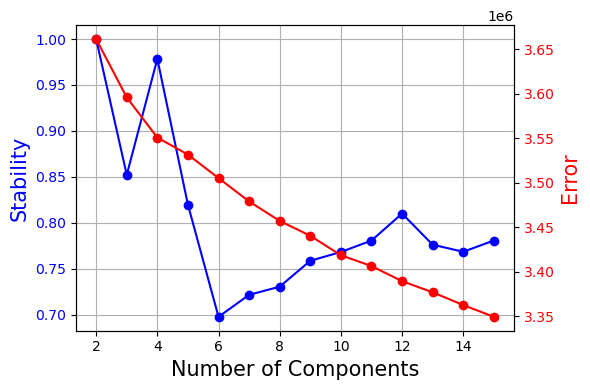

In [ ]:
cnmf_obj.prepare(
    counts_fn="../data/for_cnmf.h5ad",
    components=np.arange(2, 16), # test k from 2 to 15
    n_iter=100,
    seed=14
)

cnmf_obj.factorize(worker_i=0, total_workers=1) # Factorize

cnmf_obj.combine() # Combine results

cnmf_obj.k_selection_plot() # K selection plot


Running consensus for K=4...


/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


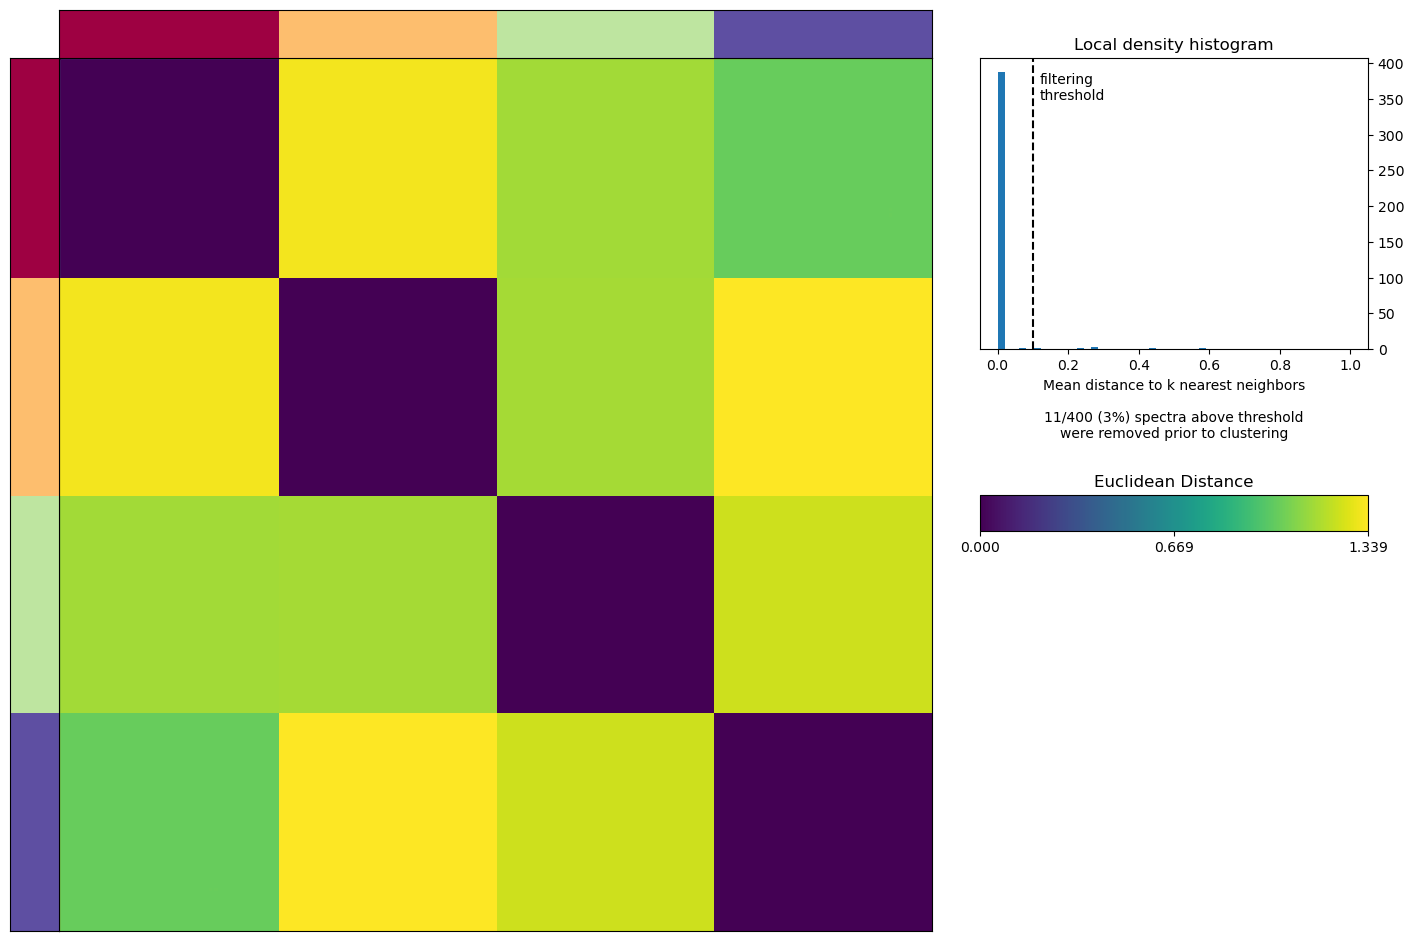

In [5]:
# k = 2, 4, 12
k_values = [4]

for k in k_values:
    print(f"\nRunning consensus for K={k}...")
    cnmf_obj.consensus(
        k=k,
        density_threshold=0.1
    )

In [4]:
adata = sc.read_h5ad('../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_075_T1.h5ad')
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

selected_K = 4

# load cNMF results and add to adata
normalized_usage_matrix, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(
    K=selected_K, density_threshold=0.1
)

for col in normalized_usage_matrix.columns:
    adata.obs[f"Program_{col}"] = normalized_usage_matrix[col].reindex(
        adata.obs_names
    ).values

sc.pp.pca(adata, use_highly_variable=True)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
adata.write_h5ad(f'{output_dir}/CCG1106_075_T1_with_programs.h5ad')

print(f"Top genes:\n{topgenes.head(50)}")

/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Top genes:
             1         2            3          4
0        KCND2    COL6A3       RNF152     APOLD1
1        CADM2    PLXDC2     CCDC102B       BUB1
2      ZNF804A    ABI3BP        ENPEP      CENPE
3        EPHA6    COL8A1        ITGA1       ANLN
4        KCTD8      MEG3        ABCC9  LINC01572
5         XKR4      SVIL         UACA       TPX2
6        ROBO2      MEG8      COL18A1      BUB1B
7        NRXN1     PTPRM       PLXDC1     GAS2L3
8      ZNF385D  MIR100HG        CARMN       ASPM
9        CDH10  MIR493HG       COL4A2  ARHGAP11A
10       MDGA2     PCNX2       PDGFRB    DEPDC1B
11       TENM2    PRSS23    LINC00989      NEIL3
12       NCAM2     TSHZ2       LHFPL6        TTK
13      LRRTM4     FOXP1      GUCY1B1      KIF15
14      LINGO2       FAP        PRKG1      KIF14
15      LRRTM3      EMP1         DLC1        CIT
16       LRP1B  ADAMTSL1          NGF       PRC1
17   LINC03000   COL14A1         SOX5      GTSE1
18     PCDH11X      LDB2       SLC6A1      NCAPG
19       

In [5]:
# Get top 100 genes per program
selected_K = 4
top_n = 100

# Create simple dataframe with programs as columns
top_genes_simple = pd.DataFrame()

for i in range(1, selected_K + 1):
    # Get top N genes for this program (already ordered by weight/score)
    program_genes = topgenes.iloc[:top_n, i-1]
    top_genes_simple[f'Program_{i}'] = program_genes.values

top_genes_simple.to_csv(f"{output_dir}/top100_genes_k4.csv", index=False)

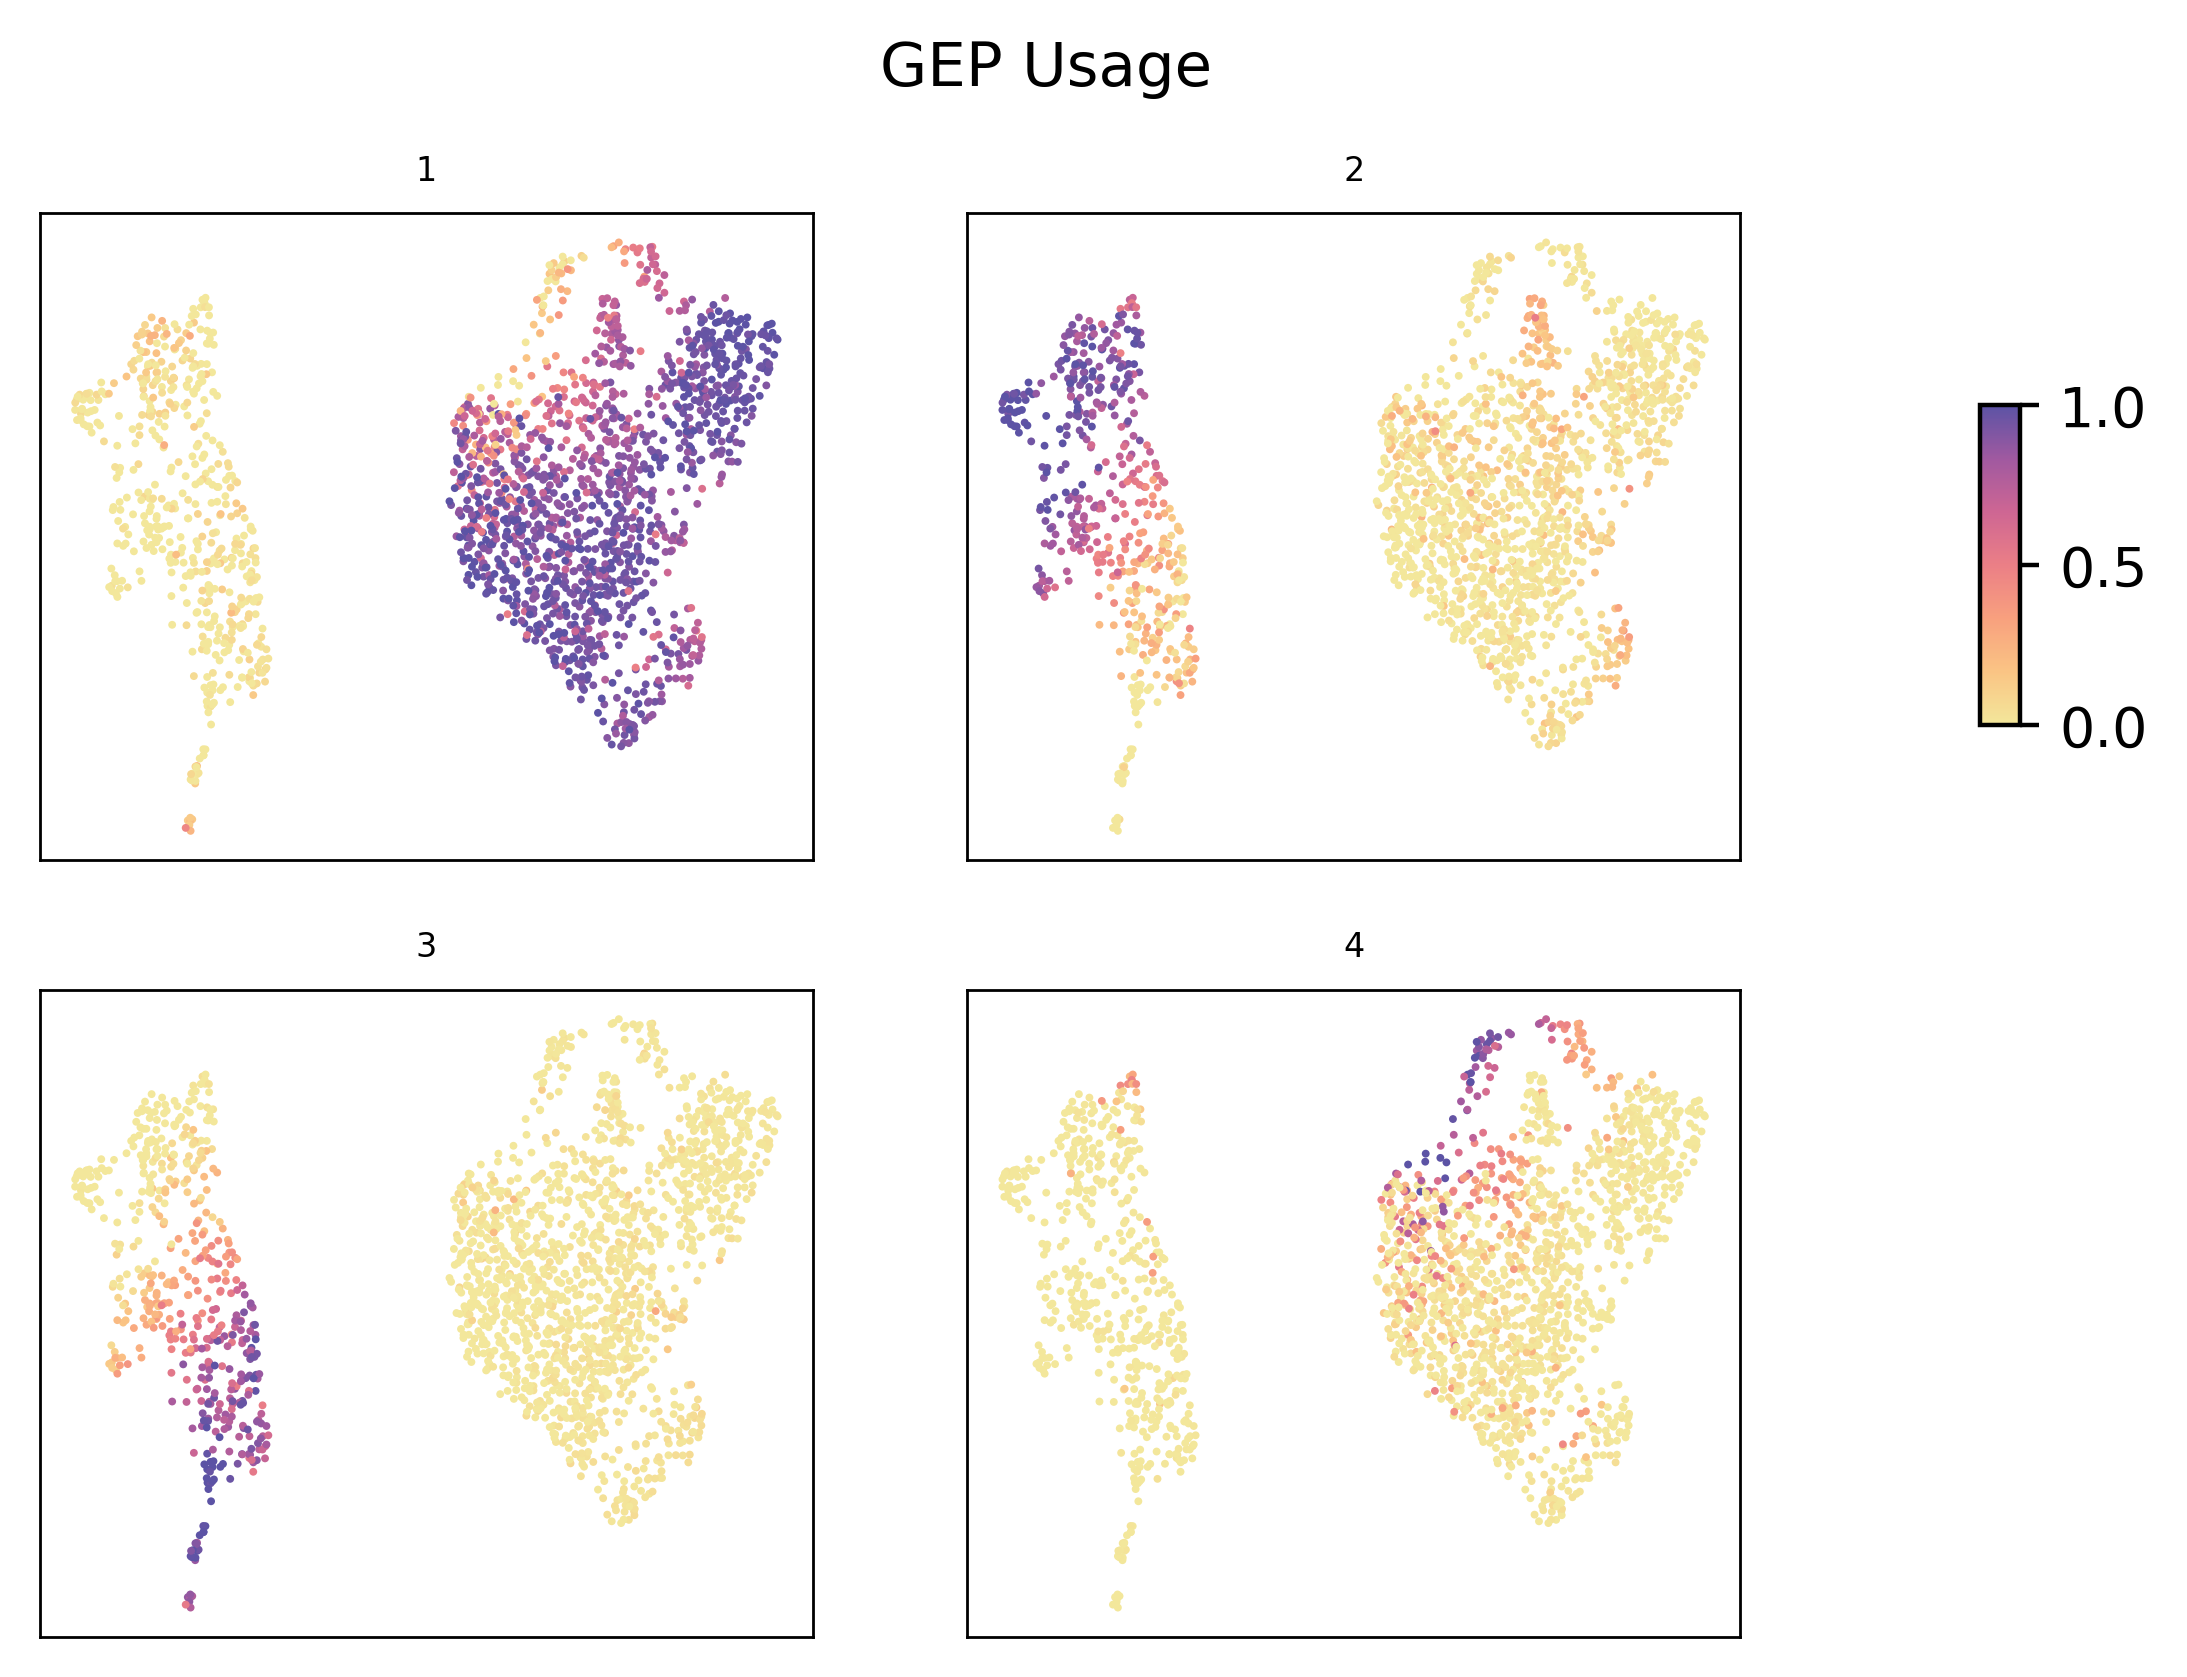

In [2]:
# start here to not rerun cnmf again
output_dir = "../outputs/cnmf_output_CCG1106_075_T1"
adata = sc.read_h5ad(f'{output_dir}/CCG1106_075_T1_with_programs.h5ad')
selected_K = 4
# Create dataframe with UMAP coords and program usage
tsne_and_usages = pd.DataFrame(
    adata.obsm['X_umap'],
    columns=['UMAP1', 'UMAP2'],
    index=adata.obs_names
)

# Add program usage
for i in range(1, selected_K + 1):
    tsne_and_usages[i] = adata.obs[f'Program_{i}'].values

cmap = palettable.cartocolors.sequential.Sunset_7.get_mpl_colormap()

# Create plot
fig, axes = plt.subplots(2, 2, figsize=(5, 4), dpi=400)
axes = axes.ravel()

for i in range(1, selected_K + 1):
    sc = axes[i-1].scatter(
        tsne_and_usages['UMAP1'], 
        tsne_and_usages['UMAP2'], 
        c=tsne_and_usages[i],
        cmap=cmap, 
        vmin=0, 
        vmax=1.0,
        s=2, 
        edgecolor='none', 
        rasterized=True
    )
    axes[i-1].set_title(f'{i}', fontsize=6)
    axes[i-1].set_xticks([])
    axes[i-1].set_yticks([])
    
    for spine in axes[i-1].spines.values():
        spine.set_linewidth(0.5)


plt.subplots_adjust(left=0.03, right=0.88, top=0.92, bottom=0.03,
                    hspace=0.20, wspace=0.20)


cbarax = fig.add_axes([1, 0.6, 0.02, 0.2])
plt.colorbar(sc, cax=cbarax)
_ = plt.figtext(0.45, 1, 'GEP Usage', fontsize=11)


plt.savefig(f"{output_dir}/UMAP_GEP_usage.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# print list of top 200 genes in program 1
# Load the spectra file
spectra = pd.read_csv("../outputs/cnmf_output_CCG1106_075_T1/CCG1106_075_T1_cNMF/CCG1106_075_T1_cNMF.gene_spectra_score.k_4.dt_0_1.txt", sep="\t", index_col=0)
program1_scores = spectra.iloc[0, :]
# Sort descending and take top 200
top200_program1 = program1_scores.sort_values(ascending=False).head(200)
top200_genes = top200_program1.index.tolist()

# print as list into a csv file
with open(f"{output_dir}/program1_top200_genes.txt", "w") as f:
    f.write(", ".join(top200_genes))

In [4]:
# supplementary table
top_n = 50
retained = list(range(1, selected_K + 1))
top_genes = {}
for prog in retained:
    scores = spectra.iloc[prog - 1, :]
    top = scores.sort_values(ascending=False).head(top_n)
    top_genes[f"Program {prog}"] = top.index.tolist()

table = pd.DataFrame(top_genes)
table.index = range(1, top_n + 1)
table.index.name = "rank"

table.to_csv(f"{output_dir}/top50_genes_programs1-4.csv")
table.head(10)

,Program 1,Program 2,Program 3,Program 4
rank,,,,
1,KCND2,COL6A3,RNF152,APOLD1
2,CADM2,PLXDC2,CCDC102B,BUB1
3,ZNF804A,ABI3BP,ENPEP,CENPE
4,EPHA6,COL8A1,ITGA1,ANLN
5,KCTD8,MEG3,ABCC9,LINC01572
6,XKR4,SVIL,UACA,TPX2
7,ROBO2,MEG8,COL18A1,BUB1B
8,NRXN1,PTPRM,PLXDC1,GAS2L3
9,ZNF385D,MIR100HG,CARMN,ASPM


dominant_program
Program 1    1345
Program 2     306
Program 3     208
Program 4      96
Name: count, dtype: int64


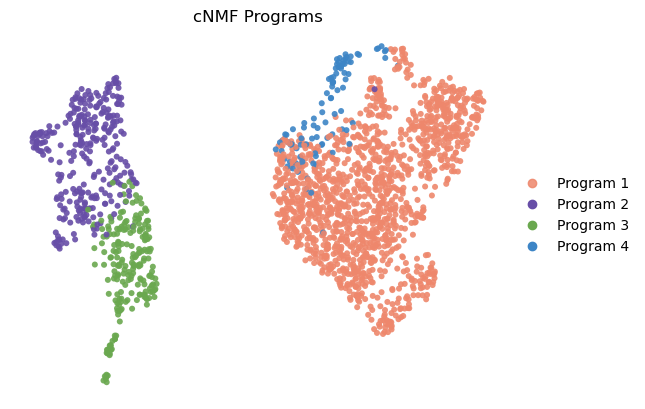

In [5]:
import scanpy as sc
import matplotlib.pyplot as plt
plt.close('all') 
# Get program columns
program_cols = [f'Program_{i}' for i in range(1, 5)]

# Assign each cell to its dominant program (highest usage score)
adata.obs['dominant_program'] = (
    adata.obs[program_cols]
    .idxmax(axis=1)  # returns e.g. 'Program_1'
    .str.replace('Program_', 'Program ')  # cosmetic
)

# Define retained programs only (1-4)
retained = ['Program 1', 'Program 2', 'Program 3', 'Program 4']
print(adata.obs['dominant_program'].value_counts()[retained])

# Label discarded program cells as 'Discarded' for clean visualization
adata.obs['program_label'] = adata.obs['dominant_program'].apply(
    lambda x: x if x in retained else 'Discarded'
)

palette = {
    'Program 1': '#ee876cdb',
    'Program 2': '#674ea7ff',
    'Program 3': '#6aa84fff',
    'Program 4': '#3d85c6ff', 
}

sc.pl.umap(
    adata,
    size=75,
    color='program_label',
    palette=palette,
    alpha=0.9,
    title='cNMF Programs',
    frameon=False,
    show=False
)
plt.savefig(f"{output_dir}/UMAP_programs_paper.pdf", dpi=300)
plt.show()
plt.close()

In [4]:
# load gene annotations
genes = pd.read_csv("../../../bulk_RNA/data/gene_coordinates.txt", sep="\t")
genes['Chromosome/scaffold name'] = genes['Chromosome/scaffold name'].replace({'X': '23', 'Y': '24'})
genes['Chromosome/scaffold name'] = pd.to_numeric(genes['Chromosome/scaffold name'])
genes = genes[(genes['Chromosome/scaffold name'] >= 1) & (genes['Chromosome/scaffold name'] <= 24)]

# Define regions of interest
regions = {
    "TP53_upstream": (17, 7000000, 22000000),
}

region_genes = {}
for name, (chrom, start, end) in regions.items():
    region_genes[name] = genes[
        (genes["Chromosome/scaffold name"] == chrom) &
        (genes["Gene start (bp)"] <= end) & 
        (genes["Gene end (bp)"] >= start)
    ]["Gene name"].dropna().tolist()

region_scores = {}
for region_name, gene_list in region_genes.items():
    genes_present = [g for g in gene_list if g in adata.var_names]
    if genes_present:
        region_data = adata[:, genes_present].X
        region_scores[f'{region_name}_score'] = (
            region_data.toarray() if hasattr(region_data, 'toarray') else region_data
        ).mean(axis=1)

# Add to AnnData
for score_name, score_values in region_scores.items():
    adata.obs[score_name] = score_values

tp53_threshold = 0.2
adata.obs['TP53_upstream_amplified'] = adata.obs['TP53_upstream_score'] > tp53_threshold

print(f"\nTP53 upstream amplified cells (>{tp53_threshold}): {adata.obs['TP53_upstream_amplified'].sum()}")


TP53 upstream amplified cells (>0.2): 1382


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_98524/3608513636.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[1].scatter(x[mask], y[mask],


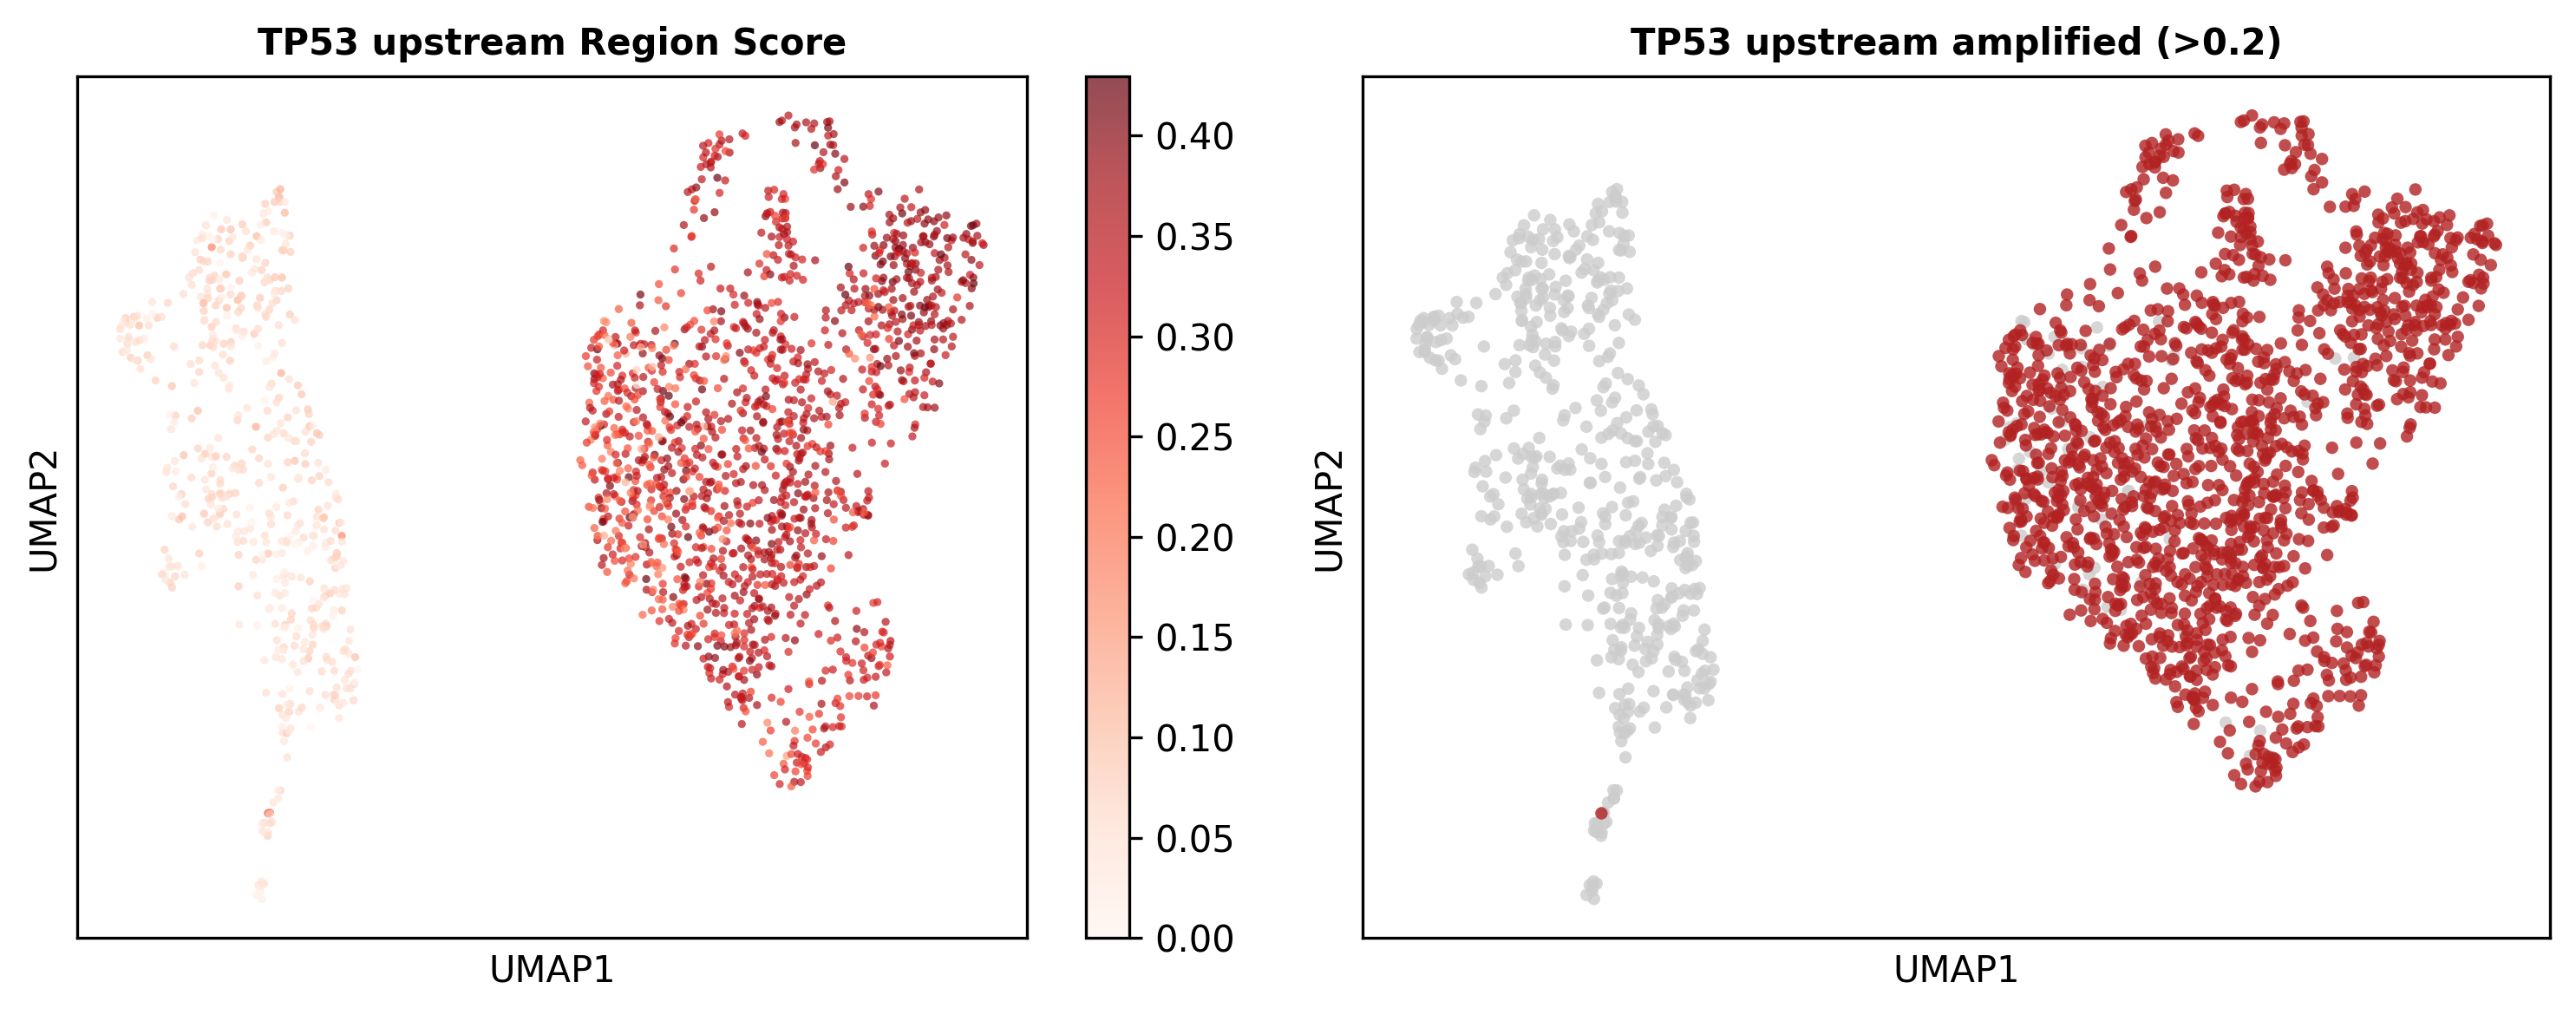

In [5]:
x = adata.obsm['X_umap'][:, 0]
y = adata.obsm['X_umap'][:, 1]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

# Plot 1: MYC score (continuous)
sc1 = axes[0].scatter(x, y, 
                      c=adata.obs['TP53_upstream_score'],
                      cmap='Reds',
                      s=5, alpha=0.7, edgecolor='none',
                      vmin=0, vmax=np.percentile(adata.obs['TP53_upstream_score'], 99))
axes[0].set_title('TP53 upstream Region Score', fontsize=10, weight='bold')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(sc1, ax=axes[0], label='')

# Plot 2: MYC amplified (binary)
colors = ['#CCCCCC', mcolors.to_rgba("#b22222", 0.58)]
labels = ['Non-amplified', 'TP53 upstream amplified']
for i, (ampl, color, label) in enumerate(zip([False, True], colors, labels)):
    mask = adata.obs['TP53_upstream_amplified'] == ampl
    axes[1].scatter(x[mask], y[mask],
                   c=color, s=12, alpha=0.8, edgecolor='none',
                   label=label)
axes[1].set_title(f'TP53 upstream amplified (>{tp53_threshold})', fontsize=10, weight='bold')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(f"{output_dir}/UMAP_TP53_upstream_score.pdf", dpi=300, bbox_inches='tight')
plt.show()

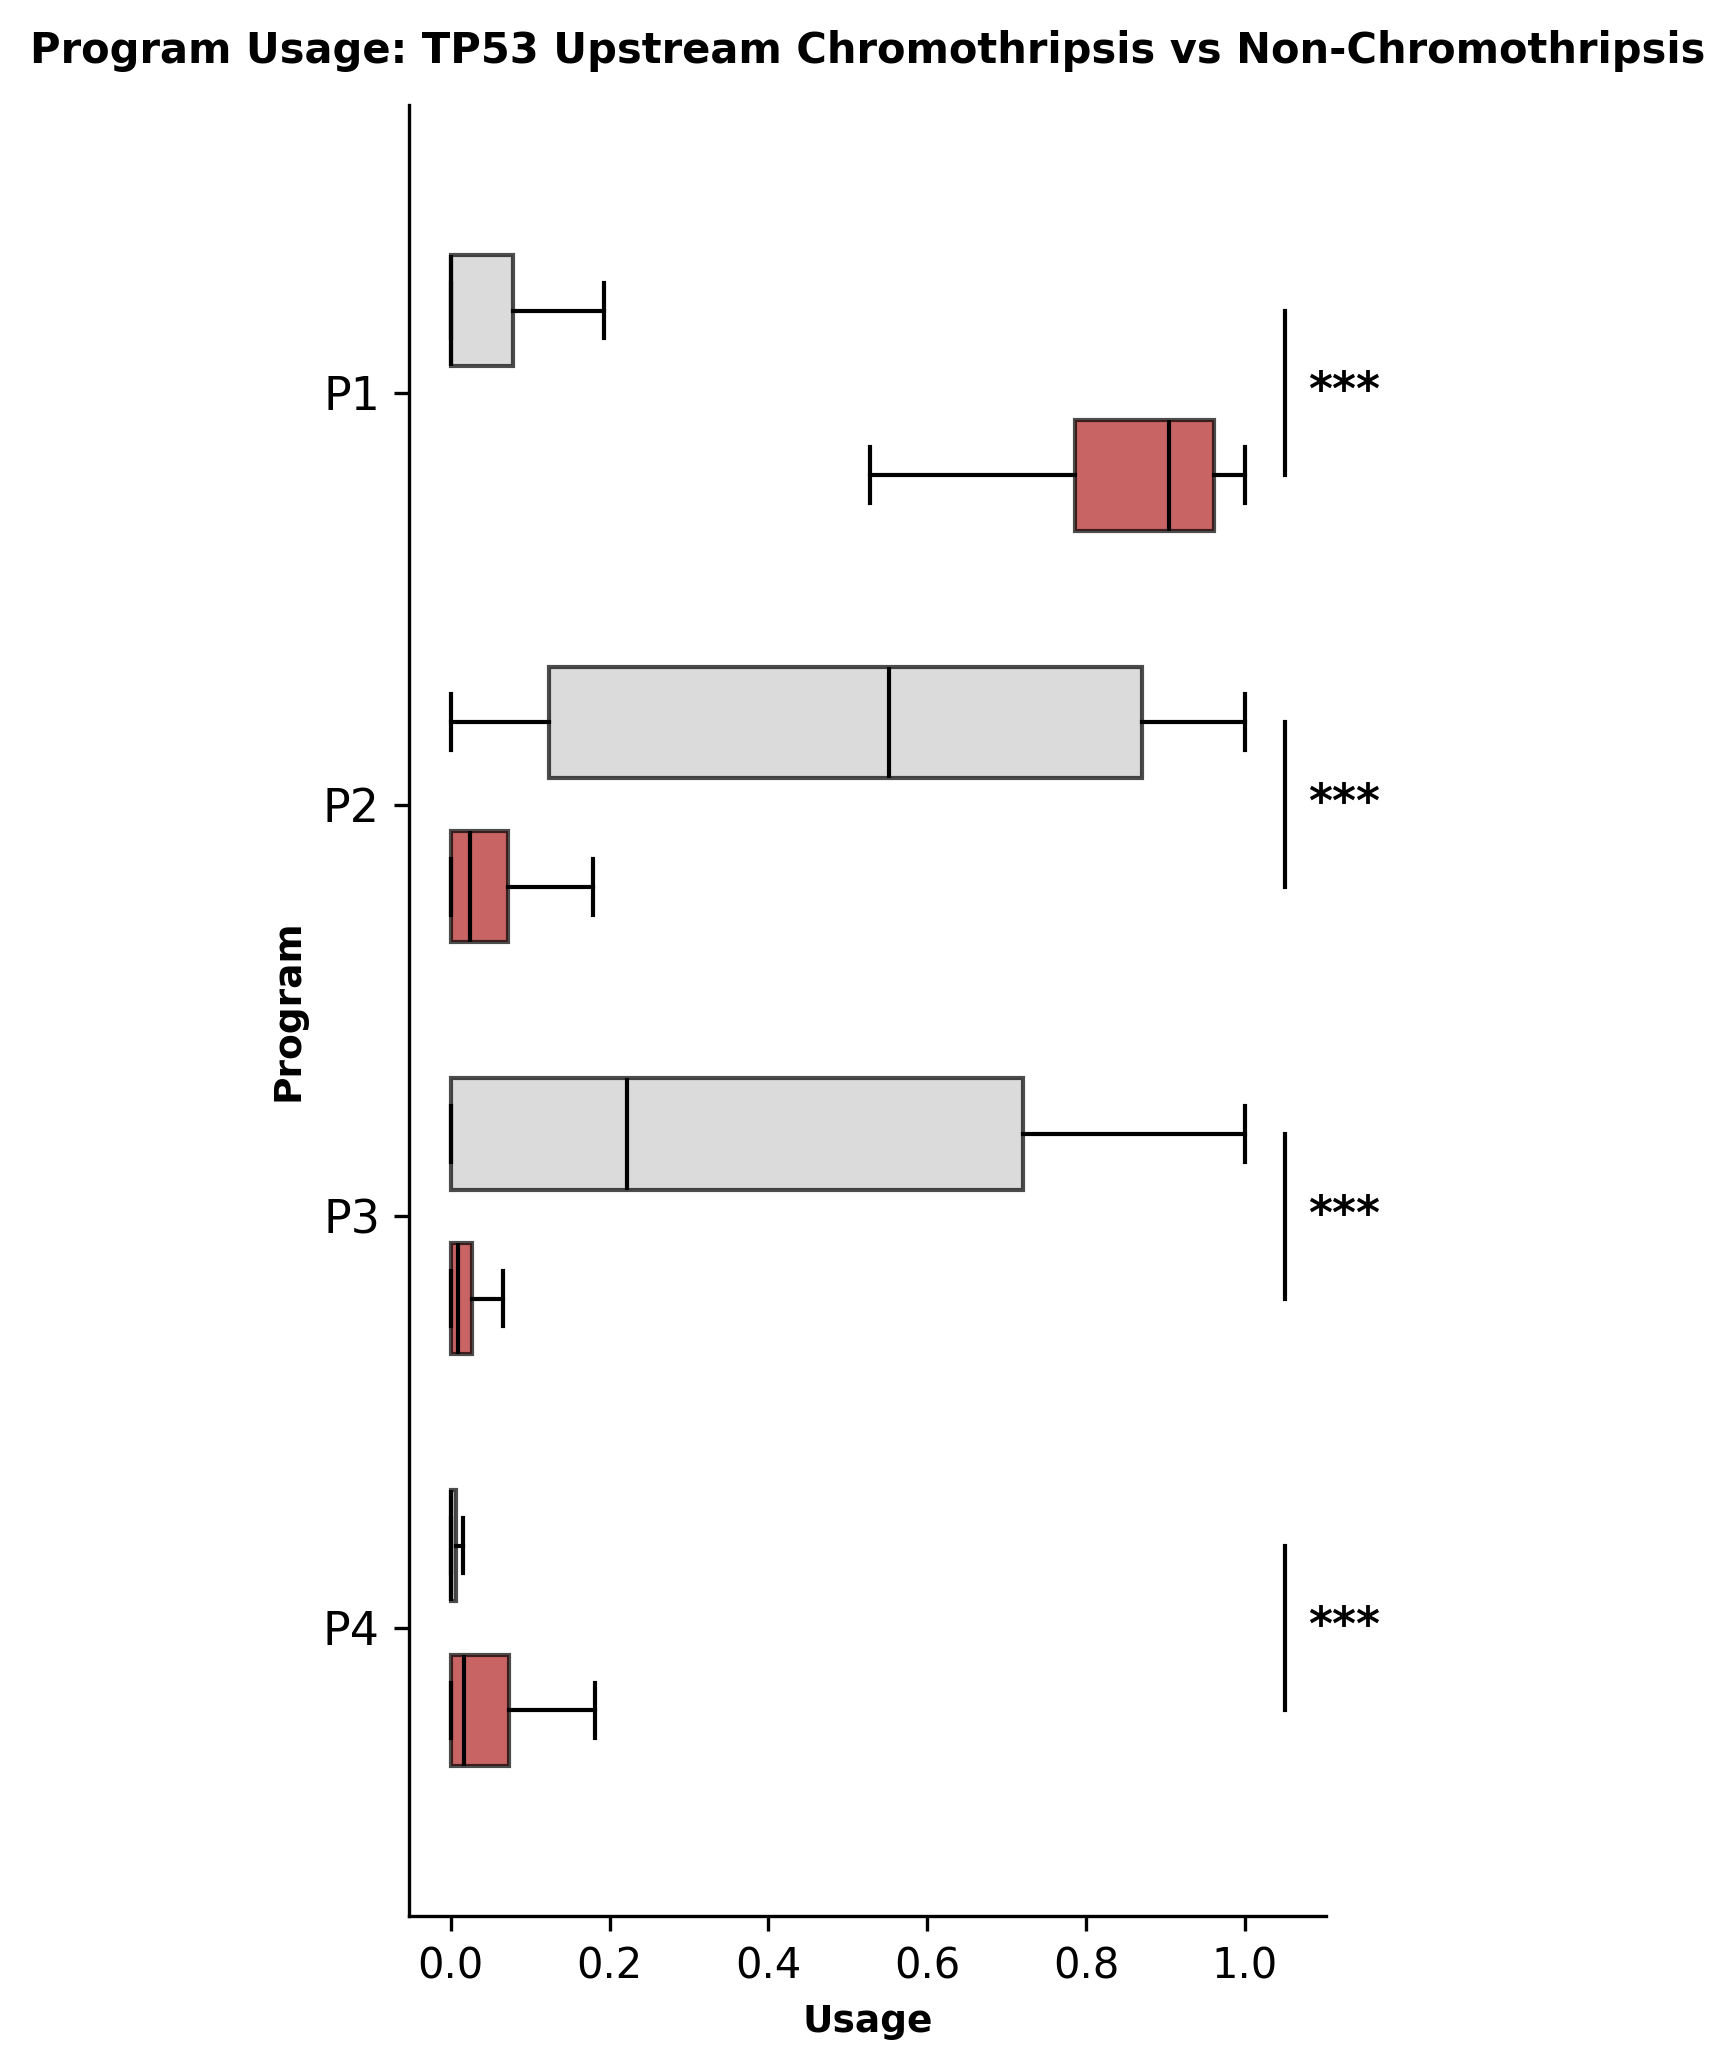


Statistical Summary:

Program 1:
  TP53-upstream-amp:  mean=0.8333, median=0.9039
  Non-amp:  mean=0.1107, median=0.0007
  Fold:     7.53x
  p-value:  5.84e-207

Program 2:
  TP53-upstream-amp:  mean=0.0486, median=0.0245
  Non-amp:  mean=0.5078, median=0.5516
  Fold:     0.10x
  p-value:  2.05e-128

Program 3:
  TP53-upstream-amp:  mean=0.0181, median=0.0092
  Non-amp:  mean=0.3496, median=0.2215
  Fold:     0.05x
  p-value:  1.90e-65

Program 4:
  TP53-upstream-amp:  mean=0.1000, median=0.0171
  Non-amp:  mean=0.0319, median=0.0000
  Fold:     3.14x
  p-value:  1.99e-49


In [6]:
# Prepare data
program_cols = [f'Program_{i}' for i in range(1, 5)]

# Reshape data for plotting
plot_data = []
for i, prog_col in enumerate(program_cols, 1):
    for idx, row in adata.obs.iterrows():
        plot_data.append({
            'Program': f'P{i}',
            'Usage': row[prog_col],
            'TP53_upstream_status': 'TP53-upstream-amp' if row['TP53_upstream_amplified'] else 'Non-amp'
        })
plot_df = pd.DataFrame(plot_data)

fig, ax = plt.subplots(figsize=(4, 7), dpi=300)

# Colors
tp53_color = '#b22222'  # red
non_tp53_color = '#CCCCCC'  # gray

# Prepare data for boxplot
positions = []
data_to_plot = []
colors = []

for i in range(1, 5):
    prog_col = f'Program_{i}'
    non_amp = adata.obs[~adata.obs['TP53_upstream_amplified']][prog_col]
    tp53_upstream_amp = adata.obs[adata.obs['TP53_upstream_amplified']][prog_col]
    
    positions.extend([i - 0.2, i + 0.2])
    data_to_plot.extend([non_amp, tp53_upstream_amp])
    colors.extend([non_tp53_color, tp53_color])

# Create boxplot
bp = ax.boxplot(data_to_plot,
                positions=positions,
                widths=0.27,
                vert=False,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color='black', linewidth=1),
                boxprops=dict(linewidth=1),
                whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

global_x_max = 0
for prog_col in program_cols:
    tp53_amp = adata.obs[adata.obs['TP53_upstream_amplified']][prog_col]
    non_amp = adata.obs[~adata.obs['TP53_upstream_amplified']][prog_col]
    global_x_max = max(global_x_max, tp53_amp.max(), non_amp.max())

# Add significance stars (using global height)
for i, prog_col in enumerate(program_cols, 1):
    tp53_amp = adata.obs[adata.obs['TP53_upstream_amplified']][prog_col]
    non_amp = adata.obs[~adata.obs['TP53_upstream_amplified']][prog_col]
    
    stat, pval = stats.mannwhitneyu(tp53_amp, non_amp, alternative='two-sided')
    
    # Determine significance level
    if pval < 0.001:
        sig_text = '***'
    elif pval < 0.01:
        sig_text = '**'
    elif pval < 0.05:
        sig_text = '*'
    else:
        sig_text = 'ns'
    
    # Use global y_max for all programs
    ax.plot([global_x_max * 1.05, global_x_max * 1.05], [i - 0.2, i + 0.2], 'k-', linewidth=1)
    ax.text(global_x_max * 1.08, i, sig_text, ha='left', va='center',
            fontsize=11, weight='bold')

ax.set_yticks(range(1, 5))
ax.set_yticklabels([f'P{i}' for i in range(1, 5)], fontsize=11)
ax.set_ylabel('Program', fontsize=9, weight='bold')
ax.set_xlabel('Usage', fontsize=9, weight='bold')
ax.set_title('Program Usage: TP53 Upstream Chromothripsis vs Non-Chromothripsis',
             fontsize=10, weight='bold', pad=10)
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{output_dir}/boxplot_program_usage_by_TP53_upstream.pdf", dpi=300, bbox_inches='tight')
plt.show()

print("\nStatistical Summary:")
print("="*70)
for i, prog_col in enumerate(program_cols, 1):
    tp53_amp = adata.obs[adata.obs['TP53_upstream_amplified']][prog_col]
    non_amp = adata.obs[~adata.obs['TP53_upstream_amplified']][prog_col]
    
    stat, pval = stats.mannwhitneyu(tp53_amp, non_amp, alternative='two-sided')
    
    print(f"\nProgram {i}:")
    print(f"  TP53-upstream-amp:  mean={tp53_amp.mean():.4f}, median={tp53_amp.median():.4f}")
    print(f"  Non-amp:  mean={non_amp.mean():.4f}, median={non_amp.median():.4f}")
    print(f"  Fold:     {tp53_amp.mean() / non_amp.mean():.2f}x")
    print(f"  p-value:  {pval:.2e}")


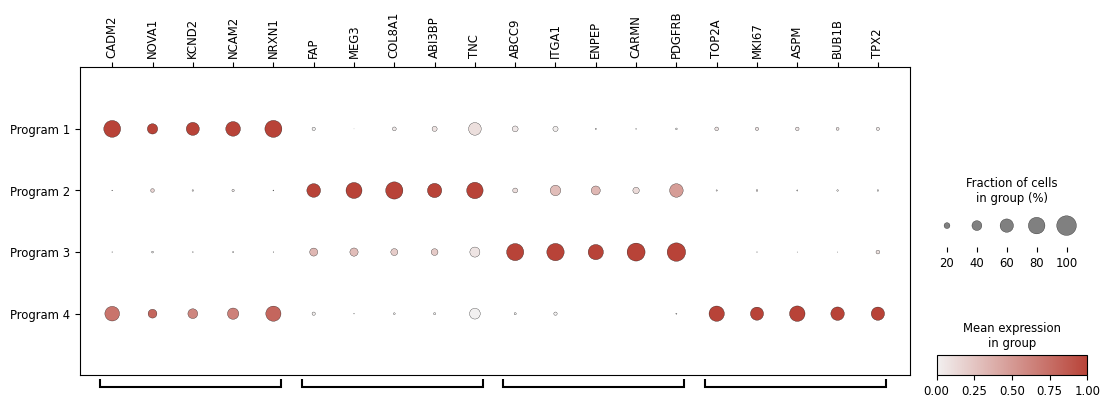

In [20]:
marker_genes = {
    'Program 1': [
        'CADM2', 'NOVA1', 'KCND2', 'NCAM2', 'NRXN1'
    ],
    'Program 2': [
        'FAP', 'MEG3', 'COL8A1', 'ABI3BP', 'TNC'
    ],
    'Program 3': [
        'ABCC9', 'ITGA1', 'ENPEP', 'CARMN', 'PDGFRB'
    ],
    'Program 4': [
        'TOP2A', 'MKI67', 'ASPM', 'BUB1B', 'TPX2'
    ]
}

# Subset to retained programs only
retained_programs = ['Program 1', 'Program 2', 'Program 3', 'Program 4']
adata_retained = adata[adata.obs['program_label'].isin(retained_programs)].copy()

dp = sc.pl.dotplot(
    adata_retained,
    var_names=marker_genes,
    groupby='program_label',
    categories_order=retained_programs,
    standard_scale='var',
    color_map=sns.light_palette((15, 70, 45), input="husl", as_cmap=True),
    dot_max=1.0,
    figsize=(13, 4),
    show=False,
    return_fig=True,
)

ax_dict = dp.get_axes()
main_ax = ax_dict['mainplot_ax']
main_ax.margins(y=0.01)
main_ax.xaxis.tick_top()
main_ax.xaxis.set_label_position('top')
plt.setp(main_ax.get_xticklabels(), rotation=90, ha='center')

# Brackets at bottom, no labels
if 'gene_group_ax' in ax_dict:
    gene_ax = ax_dict['gene_group_ax']
    main_pos = main_ax.get_position()
    gene_pos = gene_ax.get_position()
    gene_ax.set_position([
        gene_pos.x0,
        main_pos.y0 - gene_pos.height - 0.01,
        gene_pos.width,
        gene_pos.height
    ])
    gene_ax.invert_yaxis()
    for text in gene_ax.texts:
        text.set_visible(False)
    gene_ax.set_yticklabels([])


if 'color_legend_ax' in ax_dict:
    cbar_ax = ax_dict['color_legend_ax']
    pos = cbar_ax.get_position()
    # This keeps the legend in place but makes it shorter (0.3 of the plot height)
    cbar_ax.set_position([pos.x0, pos.y0, pos.width, 0.05])

plt.savefig(f"{output_dir}/program_genes_dotplot.pdf", dpi=300, bbox_inches="tight",)
plt.show()
plt.close()